In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#--1.Generate Synthetic Data--#
np.random.seed(0)
X=np.linspace(0,10,100) #100 evenly spaced x value: 0+10
#True relationshipL y= 3x+7, but we add random noise
noise = np.random.normal(0,3,size=100) #mean=0,std=3
y = 3*X+7 + noise


In [3]:
#--2.Gradient Descent--#
#Goal: find slope (m) and intercept (b) that minimize MSE loss
# MSE =(1/n)* sum(y_pred - y_actual)^^2)
#Gradient tells us which direction to move m and b reduce the error

m, b=0.0, 0.0 #start with flat line(slope=0,intercept=0)
lr =0.001 #learning rate: step size per iteration
n =len(X) #number of data points
epochs =1000 #how many times we update m and b
losses =[] # track loss so we can plot it

for epoch in range(epochs):
    y_pred = m*X+b #current prediction with these m,b

    #----Loss----#
    loss = np.mean((y_pred -y)**2) #Mean Squared Error
    losses.append(loss)

    #----Gradients (calculus chain rule)----#
    #dl/dm =(2/n)*sum((y_pred-y)*X)
    #dl/db =(2/n)*sum(y_pred-y)
    error = y_pred -y                   #residuals: shape(100,)
    dm = (2/n) * np.dot(error,X)        #dot product=sum(error*X)
    db = (2/n) * np.sum(error)

    #----Parameter Updates----#
    #Move m and b in the OPPOSITE direction of gradient {descend the slope}
    m -= lr*dm
    b -= lr*db

    if epochs %100 ==0:
        print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | m={m:.3f} | b={b:.3f}")

print(f"\nFinal -> m: {m:.3f} (true:3.0),b: {b:.3f}(true: 7.0)")




Epoch    0 | Loss: 573.0344 | m=0.271 | b=0.044
Epoch    1 | Loss: 500.0577 | m=0.524 | b=0.086
Epoch    2 | Loss: 436.7356 | m=0.759 | b=0.125
Epoch    3 | Loss: 381.7907 | m=0.978 | b=0.161
Epoch    4 | Loss: 334.1145 | m=1.183 | b=0.196
Epoch    5 | Loss: 292.7453 | m=1.373 | b=0.228
Epoch    6 | Loss: 256.8484 | m=1.550 | b=0.258
Epoch    7 | Loss: 225.6998 | m=1.715 | b=0.286
Epoch    8 | Loss: 198.6712 | m=1.868 | b=0.313
Epoch    9 | Loss: 175.2174 | m=2.011 | b=0.338
Epoch   10 | Loss: 154.8654 | m=2.144 | b=0.362
Epoch   11 | Loss: 137.2048 | m=2.268 | b=0.384
Epoch   12 | Loss: 121.8794 | m=2.384 | b=0.405
Epoch   13 | Loss: 108.5803 | m=2.491 | b=0.424
Epoch   14 | Loss: 97.0393 | m=2.591 | b=0.443
Epoch   15 | Loss: 87.0238 | m=2.685 | b=0.461
Epoch   16 | Loss: 78.3320 | m=2.771 | b=0.477
Epoch   17 | Loss: 70.7886 | m=2.852 | b=0.493
Epoch   18 | Loss: 64.2418 | m=2.927 | b=0.508
Epoch   19 | Loss: 58.5597 | m=2.998 | b=0.522
Epoch   20 | Loss: 53.6278 | m=3.063 | b=0.535

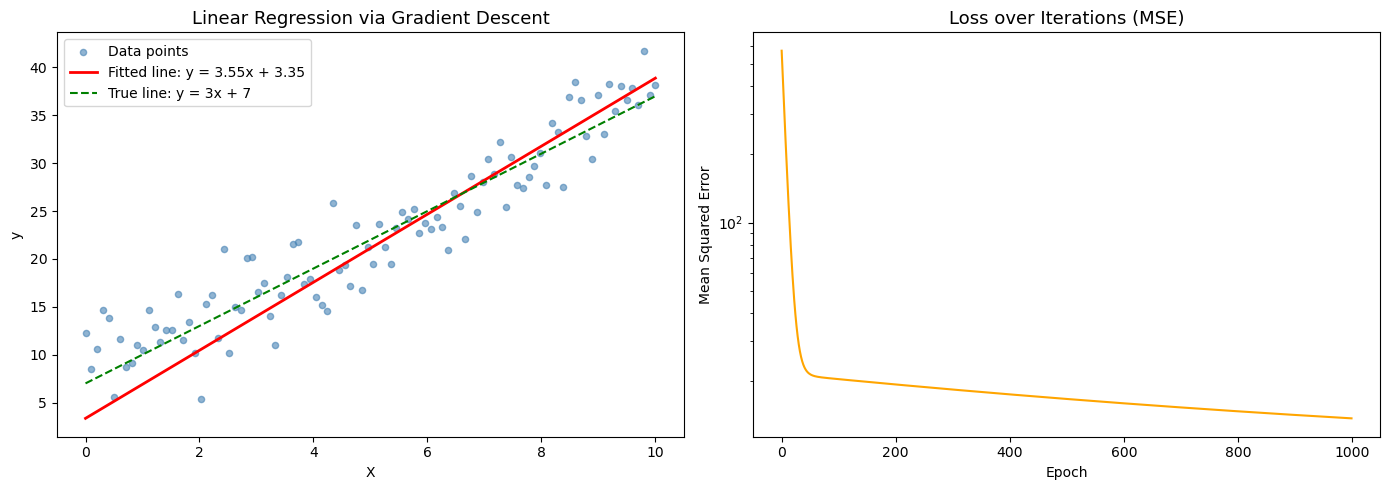

In [4]:
#--3.PLOT:2 Panels--#
fig, (ax1,ax2) =plt.subplots(1,2,figsize=(14,5))

#Panel 1: Data+ RegressionLine
ax1.scatter(X, y, color='steelblue', alpha=0.6, s=20, label='Data points')
ax1.plot(X, m * X + b, color='red', linewidth=2,
         label=f'Fitted line: y = {m:.2f}x + {b:.2f}')
ax1.plot(X, 3*X + 7, color='green', linewidth=1.5,
         linestyle='--', label='True line: y = 3x + 7')
ax1.set_title('Linear Regression via Gradient Descent', fontsize=13)
ax1.set_xlabel('X')
ax1.set_ylabel('y')
ax1.legend()

# Panel 2: Loss Curve
ax2.plot(losses, color='orange', linewidth=1.5)
ax2.set_title('Loss over Iterations (MSE)', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean Squared Error')
ax2.set_yscale('log')                       # log scale shows the drop clearly

plt.tight_layout()
plt.savefig('linear_regression.png', dpi=150)
plt.show()